# Tree Models - Phase 5

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
# Load Data

train_df = pd.read_csv("data/processed/train_2010_2022.csv")
test_df = pd.read_csv("data/processed/test_2023_2025.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (120, 17)
Test: (34, 17)


In [3]:
# Define Features and Targets

numeric_features = [
    "draft_pick_overall",
    "age_on_draft_day",
    "height_inches",
    "weight_lbs",
    "college_games_played",
    "career_yards",
    "career_touchdowns"
]

categorical_features = [
    "position"
]

target_regression = "rookie_total_ppr_points"
target_classification = "fantasy_relevant_binary"

In [4]:
# Create X and y

X_train = train_df[numeric_features + categorical_features]
X_test = test_df[numeric_features + categorical_features]

y_train_reg = train_df[target_regression]
y_test_reg = test_df[target_regression]

y_train_class = train_df[target_classification]
y_test_class = test_df[target_classification]

In [5]:
# Build Tree Preproccessing Pipeline

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [ ]:
# Helper Function for Regression Metrics

def regression_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "model": model_name,
        "task": "Regression",
        "MAE": mae,
        "RMSE": rmse,
        "Accuracy": np.nan,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "ROC_AUC": np.nan
    }

In [8]:
# Helper Function for Classification Metrics

def classification_metrics(y_true, y_pred, y_prob, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan

    return {
        "model": model_name,
        "task": "Classification",
        "MAE": np.nan,
        "RMSE": np.nan,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": auc
    }

In [9]:
# Decision Tree Regressor

tree_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=3,
        random_state=88
    ))
])

tree_reg.fit(X_train, y_train_reg)
tree_reg_preds = tree_reg.predict(X_test)

tree_reg_results = regression_metrics(
    y_test_reg,
    tree_reg_preds,
    "Decision Tree Regressor"
)

tree_reg_results

{'model': 'Decision Tree Regressor',
 'task': 'Regression',
 'MAE': 77.82450048349703,
 'RMSE': np.float64(98.05407062478906),
 'Accuracy': nan,
 'Precision': nan,
 'Recall': nan,
 'F1': nan,
 'ROC_AUC': nan}

In [10]:
# Random Forest Regressor

rf_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_depth=4,
        random_state=88
    ))
])

rf_reg.fit(X_train, y_train_reg)
rf_reg_preds = rf_reg.predict(X_test)

rf_reg_results = regression_metrics(
    y_test_reg,
    rf_reg_preds,
    "Random Forest Regressor"
)

rf_reg_results

{'model': 'Random Forest Regressor',
 'task': 'Regression',
 'MAE': 77.04317602603263,
 'RMSE': np.float64(94.26668137823158),
 'Accuracy': nan,
 'Precision': nan,
 'Recall': nan,
 'F1': nan,
 'ROC_AUC': nan}

In [11]:
# Decision Tree Classifier

tree_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        random_state=88
    ))
])

tree_clf.fit(X_train, y_train_class)

tree_clf_preds = tree_clf.predict(X_test)
tree_clf_probs = tree_clf.predict_proba(X_test)[:, 1]

tree_clf_results = classification_metrics(
    y_test_class,
    tree_clf_preds,
    tree_clf_probs,
    "Decision Tree Classifier"
)

tree_clf_results

{'model': 'Decision Tree Classifier',
 'task': 'Classification',
 'MAE': nan,
 'RMSE': nan,
 'Accuracy': 0.5294117647058824,
 'Precision': 0.6666666666666666,
 'Recall': 0.2222222222222222,
 'F1': 0.3333333333333333,
 'ROC_AUC': 0.6666666666666666}

In [12]:
# Random Forest Classifier

rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        random_state=88,
        class_weight="balanced"
    ))
])

rf_clf.fit(X_train, y_train_class)

rf_clf_preds = rf_clf.predict(X_test)
rf_clf_probs = rf_clf.predict_proba(X_test)[:, 1]

rf_clf_results = classification_metrics(
    y_test_class,
    rf_clf_preds,
    rf_clf_probs,
    "Random Forest Classifier"
)

rf_clf_results

{'model': 'Random Forest Classifier',
 'task': 'Classification',
 'MAE': nan,
 'RMSE': nan,
 'Accuracy': 0.5882352941176471,
 'Precision': 0.625,
 'Recall': 0.5555555555555556,
 'F1': 0.5882352941176471,
 'ROC_AUC': 0.6631944444444444}

In [13]:
# Combine Tree Results

tree_results = pd.DataFrame([
    tree_reg_results,
    rf_reg_results,
    tree_clf_results,
    rf_clf_results
])

tree_results

,model,task,MAE,RMSE,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree Regressor,Regression,77.824500,98.054071,NaN,NaN,NaN,NaN,NaN
1,Random Forest Regressor,Regression,77.043176,94.266681,NaN,NaN,NaN,NaN,NaN
2,Decision Tree Classifier,Classification,NaN,NaN,0.529412,0.666667,0.222222,0.333333,0.666667
3,Random Forest Classifier,Classification,NaN,NaN,0.588235,0.625000,0.555556,0.588235,0.663194


In [14]:
# Load Baseline Results and Compare

baseline_results = pd.read_csv("data/processed/baseline_model_results.csv")

all_results = pd.concat(
    [baseline_results, tree_results],
    axis=0,
    ignore_index=True
)

all_results

,model,task,MAE,RMSE,Accuracy,Precision,Recall,F1,ROC_AUC
0,Linear Regression,Regression,81.930322,97.200703,NaN,NaN,NaN,NaN,NaN
1,Logistic Regression,Classification,NaN,NaN,0.500000,0.555556,0.277778,0.370370,0.642361
2,Decision Tree Regressor,Regression,77.824500,98.054071,NaN,NaN,NaN,NaN,NaN
3,Random Forest Regressor,Regression,77.043176,94.266681,NaN,NaN,NaN,NaN,NaN
4,Decision Tree Classifier,Classification,NaN,NaN,0.529412,0.666667,0.222222,0.333333,0.666667
5,Random Forest Classifier,Classification,NaN,NaN,0.588235,0.625000,0.555556,0.588235,0.663194


In [15]:
# Save Results

all_results.to_csv("data/processed/model_results_phase5.csv", index=False)

print("Phase 5 results saved.")

Phase 5 results saved.


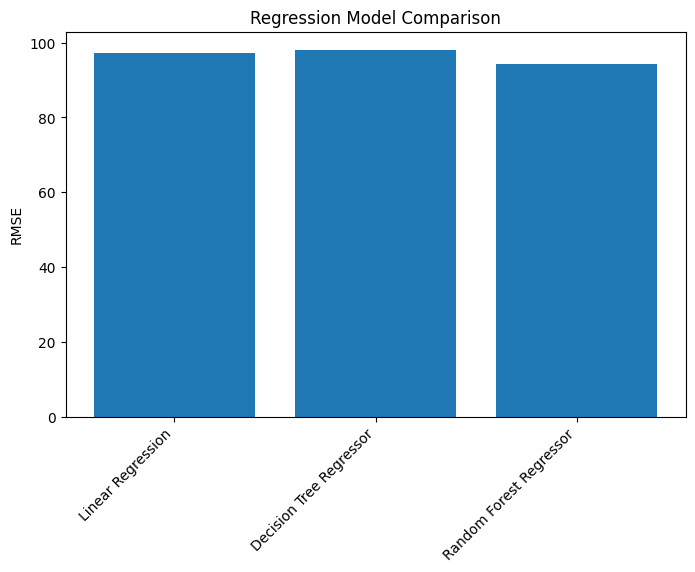

In [16]:
# Regression Comparison Plot

reg_results = all_results[all_results["task"] == "Regression"]

plt.figure(figsize=(8, 5))
plt.bar(reg_results["model"], reg_results["RMSE"])
plt.ylabel("RMSE")
plt.title("Regression Model Comparison")
plt.xticks(rotation=45, ha="right")
plt.show()

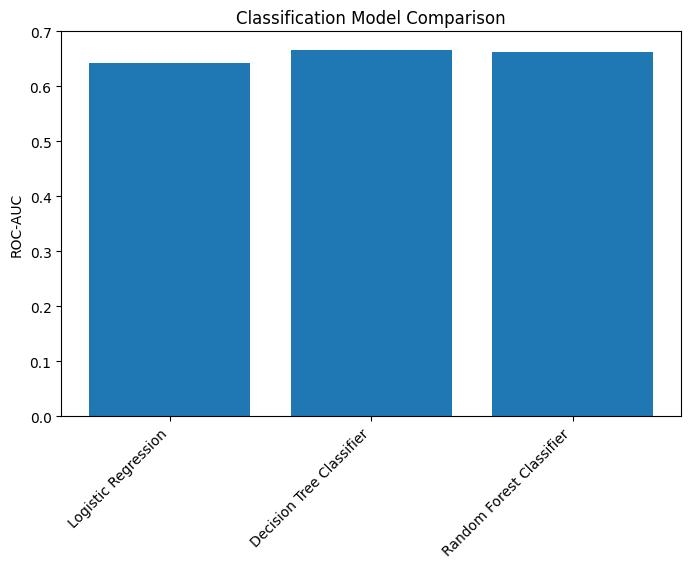

In [17]:
# Classification Comparison Plot

clf_results = all_results[all_results["task"] == "Classification"]

plt.figure(figsize=(8, 5))
plt.bar(clf_results["model"], clf_results["ROC_AUC"])
plt.ylabel("ROC-AUC")
plt.title("Classification Model Comparison")
plt.xticks(rotation=45, ha="right")
plt.show()